In [1]:
import argparse
import os
import pathlib
import sys
import time

import bioio
import matplotlib.pyplot as plt
import natsort
import numpy as np
import pandas as pd
import seaborn as sns
from timelapse_utils.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)

root_dir, in_notebook = init_notebook()
if in_notebook:
    import tqdm.notebook as tqdm
else:
    import tqdm
image_based_dir = bandicoot_check(
    bandicoot_mount_path=pathlib.Path(f"{os.path.expanduser('~')}/mnt/bandicoot/"),
    root_dir=root_dir,
)
image_based_dir = image_based_dir / "processed_data"
print(image_based_dir)

/home/lippincm/mnt/bandicoot/live_cell_timelapse_pyroptosis_project_data/processed_data


In [2]:
def measure_intensity_features(image: np.ndarray):
    """
    Measure intensity features of the image.

    Parameters:
    image (np.ndarray): Input image.

    Returns:
    dict: Dictionary containing intensity features.
    """
    min_intensity = np.min(image)
    max_intensity = np.max(image)
    mean_intensity = np.mean(image)
    median_intensity = np.median(image)
    std_intensity = np.std(image)
    lower_quartile = np.percentile(image, 25)
    upper_quartile = np.percentile(image, 75)

    return {
        "min": min_intensity,
        "max": max_intensity,
        "mean": mean_intensity,
        "median": median_intensity,
        "std": std_intensity,
        "lower_quartile": lower_quartile,
        "upper_quartile": upper_quartile,
    }

In [3]:
if not in_notebook:
    args = argparse.ArgumentParser()
    args.add_argument(
        "--plate_name",
        type=str,
        required=True,
        help="Name of the plate to process (e.g. '2023-08-01_plate1')",
    )
    plate_name = args.parse_args().plate_name
else:
    plate_name = "plate_2"

In [4]:
# concated output file
checkpoint_path = pathlib.Path("../results").resolve()
checkpoint_path.mkdir(parents=True, exist_ok=True)

final_df_path = checkpoint_path / "intensity_features_final.parquet"


# get a list of the well_fov directories for each patient
well_fov_dirs = [
    x
    for x in pathlib.Path(f"{image_based_dir}/0.renamed_files/{plate_name}").iterdir()
    if x.is_dir()
]
# get timepoints per well_fov
well_fov_timepoint_raw_file_paths = []
for well_fov_dir in tqdm.tqdm(well_fov_dirs):
    timepoint_dirs = sorted(well_fov_dir.glob("*"))
    for timepoint_dir in timepoint_dirs:
        well_fov_timepoint_raw_file_paths.append(timepoint_dir)
well_fov_df = pd.DataFrame(
    {
        "well_fov_timepoint": [x for x in well_fov_timepoint_raw_file_paths],
    }
)
well_fov_df["well_fov"] = well_fov_df["well_fov_timepoint"].apply(
    lambda x: "_".join(x.name.split("_")[:2])
)
well_fov_df["channel"] = well_fov_df["well_fov_timepoint"].apply(
    lambda x: x.name.split("_")[3].strip(".tiff")
)
well_fov_df["timepoint"] = well_fov_df["well_fov_timepoint"].apply(
    lambda x: x.name.split("_")[2]
)
# keep T prefix and pad only the numeric part to 4 digits (e.g., T9 -> T0009)
well_fov_df["timepoint"] = well_fov_df["timepoint"].apply(
    lambda x: f"T{str(x)[1:].zfill(4)}"
    if str(x).startswith("T")
    else f"T{str(x).zfill(4)}"
)

well_fov_df.drop_duplicates(subset=["well_fov", "channel", "timepoint"], inplace=True)

  0%|          | 0/160 [00:00<?, ?it/s]

In [5]:
# sort the df
well_fov_df.sort_values(by=["well_fov", "channel", "timepoint"], inplace=True)
# natural sort the df by well_fov and timepoint
well_fov_df = well_fov_df.iloc[
    natsort.index_natsorted(
        well_fov_df["well_fov"].astype(str)
        + "_"
        + well_fov_df["channel"].astype(str)
        + "_"
        + well_fov_df["timepoint"].astype(str)
    )
].reset_index(drop=True)

In [6]:
# pivot wide where each channel gets its own column, and the values are the well_fov_timepoint paths
well_fov_df_wide = well_fov_df.pivot(
    index=["well_fov", "timepoint"], columns="channel", values="well_fov_timepoint"
).reset_index()
well_fov_df_wide.head()
well_fov_df_wide.rename(
    columns={
        "C1": "file_path_C1",
        "C2": "file_path_C2",
        "C3": "file_path_C3",
        "C4": "file_path_C4",
    },
    inplace=True,
)
print(well_fov_df_wide.shape)
# well_fov_df_wide = well_fov_df_wide.head(500)

(46080, 6)


In [7]:
N = 500  # save a checkpoint every N rows processed

rows_processed_since_save = 0
if final_df_path.exists():
    rows_processed_since_save = pd.read_parquet(final_df_path).shape[0]
# --- Resume from checkpoint if it exists ---
elif os.path.exists(checkpoint_path):
    checkpoints = list(checkpoint_path.glob("*"))
    if checkpoints:
        numbered_checkpoints = [
            int(str(checkpoint.stem).split("_")[0].split(".")[0])
            for checkpoint in checkpoints
        ]

        rows_processed_since_save = max(numbered_checkpoints)
        print(f"Resuming from checkpoint: {rows_processed_since_save} rows processed")

output_dict = {
    "well_fov": [],
    "timepoint": [],
    "channel": [],
    "min": [],
    "max": [],
    "mean": [],
    "median": [],
    "std": [],
    "lower_quartile": [],
    "upper_quartile": [],
}

In [8]:
for row in tqdm.tqdm(
    well_fov_df_wide.itertuples(),
    desc="Processing well_fov and timepoints",
    unit="row",
    total=len(well_fov_df_wide),
):
    if row.Index < rows_processed_since_save:
        continue  # Skip already processed rows
    image1_features = measure_intensity_features(bioio.BioImage(row.file_path_C1).data)
    image2_features = measure_intensity_features(bioio.BioImage(row.file_path_C2).data)
    image3_features = measure_intensity_features(bioio.BioImage(row.file_path_C3).data)
    image4_features = measure_intensity_features(bioio.BioImage(row.file_path_C4).data)

    for channel, features in zip(
        ["C1", "C2", "C3", "C4"],
        [image1_features, image2_features, image3_features, image4_features],
    ):
        output_dict["well_fov"].append(row.well_fov)
        output_dict["timepoint"].append(row.timepoint)
        output_dict["channel"].append(channel)
        output_dict["min"].append(features["min"])
        output_dict["max"].append(features["max"])
        output_dict["mean"].append(features["mean"])
        output_dict["median"].append(features["median"])
        output_dict["std"].append(features["std"])
        output_dict["lower_quartile"].append(features["lower_quartile"])
        output_dict["upper_quartile"].append(features["upper_quartile"])

    rows_processed_since_save += 1

    # --- Save checkpoint every N rows ---
    if rows_processed_since_save % N == 0:
        checkpoint_file = (
            checkpoint_path / f"{rows_processed_since_save}_rows_checkpoint.parquet"
        )
        pd.DataFrame(output_dict).to_parquet(checkpoint_file, index=False)
        output_dict = {
            "well_fov": [],
            "timepoint": [],
            "channel": [],
            "min": [],
            "max": [],
            "mean": [],
            "median": [],
            "std": [],
            "lower_quartile": [],
            "upper_quartile": [],
        }

Processing well_fov and timepoints:   0%|          | 0/46080 [00:00<?, ?row/s]

In [9]:
if not final_df_path.exists():
    final_df_path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.concat(
        [pd.read_parquet(checkpoint) for checkpoint in checkpoint_path.glob("*")],
        ignore_index=True,
    )
    df["timepoint"] = df["timepoint"].apply(lambda x: x.strip("T")).astype(int)
    df.to_parquet(final_df_path, index=False)

else:
    df = pd.read_parquet(final_df_path)
print(f"Final DataFrame shape: {df.shape}")
df.head()

Final DataFrame shape: (184000, 10)


,well_fov,timepoint,channel,min,max,mean,median,std,lower_quartile,upper_quartile
0,J3_1,201,C1,101,1177,104.003563,102.0,9.311305,101.0,105.0
1,J3_1,201,C2,101,2802,350.007145,170.0,324.142965,133.0,488.0
2,J3_1,201,C3,101,8342,366.615274,110.0,806.744178,103.0,159.0
3,J3_1,201,C4,0,2881,140.640080,105.0,118.732247,101.0,113.0
4,J3_1,202,C1,101,848,104.005200,102.0,8.675724,101.0,105.0


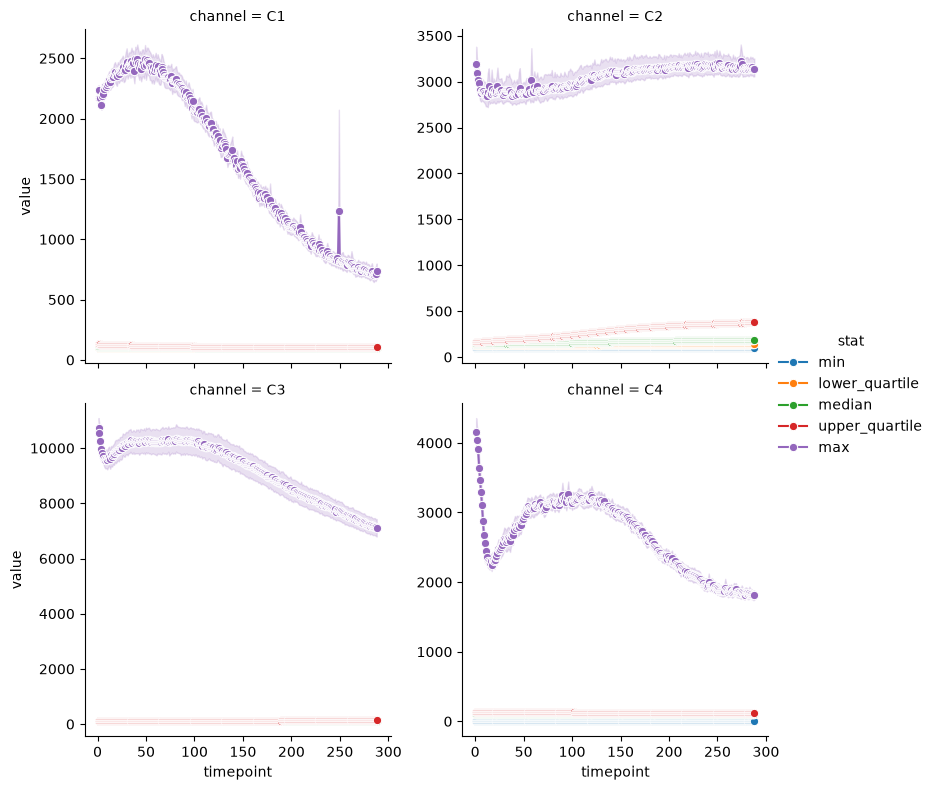

In [10]:
melted = df.melt(
    id_vars=["well_fov", "timepoint", "channel"],
    value_vars=["min", "lower_quartile", "median", "upper_quartile", "max"],
    var_name="stat",
    value_name="value",
)

# g = sns.FacetGrid(melted, col='channel', col_wrap=2, hue='stat', sharey=False, height=4)
# # g.map(sns.lineplot, 'timepoint', 'value', marker='o')
# g.map(sns.boxenplot, 'timepoint', 'value')
# g.add_legend()
# plt.show()
g = sns.FacetGrid(melted, col="channel", col_wrap=2, hue="stat", sharey=False, height=4)
g.map(sns.lineplot, "timepoint", "value", marker="o")
g.add_legend()
plt.show()

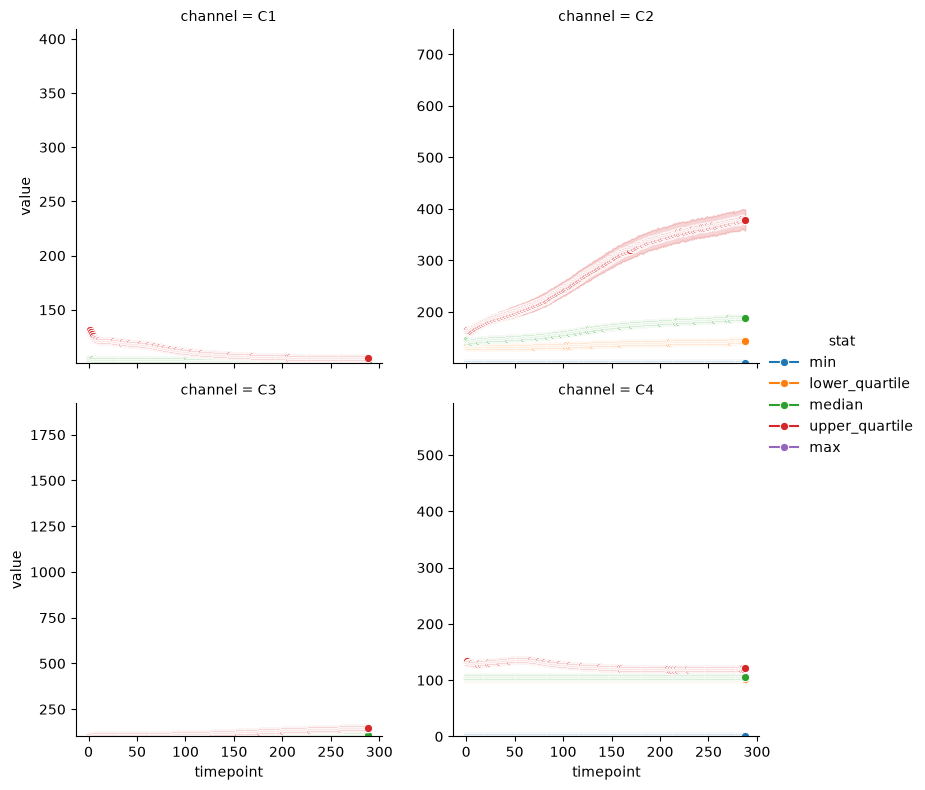

In [12]:
melted = df.melt(
    id_vars=["well_fov", "timepoint", "channel"],
    value_vars=["min", "lower_quartile", "median", "upper_quartile", "max"],
    var_name="stat",
    value_name="value",
)

g = sns.FacetGrid(melted, col="channel", col_wrap=2, hue="stat", sharey=False, height=4)
g.map(sns.lineplot, "timepoint", "value", marker="o")
g.add_legend()
# limit the y-axis to the range of the data for each channel
for ax, channel in zip(g.axes.flat, ["C1", "C2", "C3", "C4"]):
    channel_data = melted[melted["channel"] == channel]
    ax.set_ylim(channel_data["value"].min(), channel_data["value"].mean())
plt.show()